In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [2]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.6 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO

print("Ultralytics imported successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics imported successfully!


In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
import os

DATASET_DIR = "/content/drive/MyDrive/PCB-Defect-Inspection-lsp/dataset_limszeping_set1"

print(os.path.exists(DATASET_DIR))
print(os.listdir(DATASET_DIR))

True
['images', 'labels', 'data.yaml', 'set1 normal&segmentation.zip']


In [ ]:
from pathlib import Path

dataset = Path(DATASET_DIR)

for split in ["train", "val", "test"]:
    image_dir = dataset / "images" / split
    label_dir = dataset / "labels" / split

    image_files = [
        f for f in image_dir.rglob("*")
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    label_files = list(label_dir.glob("*.txt"))

    print(f"\n{split.upper()}")
    print("Images :", len(image_files))
    print("Labels :", len(label_files))


TRAIN
Images : 481
Labels : 481

VAL
Images : 60
Labels : 60

TEST
Images : 152
Labels : 152


In [ ]:
from pathlib import Path

DATASET_DIR = Path(
    "/content/drive/MyDrive/PCB-Defect-Inspection-lsp/dataset_limszeping_set1"
)

print("Dataset:", DATASET_DIR.exists())
print("Train:", (DATASET_DIR / "images/train").exists())
print("Val:", (DATASET_DIR / "images/val").exists())
print("Test:", (DATASET_DIR / "images/test").exists())

Dataset: True
Train: True
Val: True
Test: True


In [37]:
#Train Set 1
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/drive/MyDrive/PCB-Defect-Inspection/dataset_limszeping_set1/data.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    patience=0,
    seed=42,
    project="/content/drive/MyDrive/PCB-Defect-Inspection/runs",
    name="pcb_set1_100epochs"
)

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/PCB-Defect-Inspection/dataset_limszeping_set1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, nam

RuntimeError: Dataset '/content/drive/MyDrive/PCB-Defect-Inspection/dataset_limszeping_set1/data.yaml' error ❌ '/content/drive/MyDrive/PCB-Defect-Inspection/dataset_limszeping_set1/data.yaml' does not exist

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/PCB-Defect-Inspection-lsp/runs/pcb_set1_100epochs/weights/best.pt"
)

results = model.val(
    data="/content/drive/MyDrive/PCB-Defect-Inspection-lsp/dataset_limszeping_set1/data.yaml",
    split="test",
    imgsz=640,
    batch=8
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.7±0.2 ms, read: 3.2±1.0 MB/s, size: 2581.6 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/PCB-Defect-Inspection/dataset_limszeping_set1/labels/test... 152 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 152/152 1.4s/it 3:38
val: New cache created: /content/drive/MyDrive/PCB-Defect-Inspection/dataset_limszeping_set1/labels/test.cache
WARNING ⚠️ Dataset images contain up to 886 objects (test=886), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=886 to match the observed maximum.
  

In [ ]:
!cp -r /content/runs/detect/val \
"/content/drive/MyDrive/PCB-Defect-Inspection-lsp/runs/pcb_set1_test"

In [ ]:
import pandas as pd

test_results = pd.DataFrame([{
    "Set": "Set 1",
    "Precision": 0.653,
    "Recall": 0.483,
    "F1-score": 0.555,
    "mAP50": 0.475,
    "mAP50-95": 0.229
}])

save_path = "/content/drive/MyDrive/PCB-Defect-Inspection-lsp/runs/pcb_set1_test/test_results.csv"

test_results.to_csv(save_path, index=False)

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/PCB-Defect-Inspection/runs/pcb_set1_test/test_results.csv


In [ ]:
import os

DATASET_DIR = "/content/drive/MyDrive/PCB-Defect-Inspection-lsp/dataset_limszeping_set2"

print(os.path.exists(DATASET_DIR))
print(os.listdir(DATASET_DIR))

True
['data.yaml', 'images', 'labels']


In [ ]:
#Train Set 2
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/drive/MyDrive/PCB-Defect-Inspection-lsp/dataset_limszeping_set2/data.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    patience=0,
    seed=42,
    project="/content/drive/MyDrive/PCB-Defect-Inspection-lsp/runs",
    name="pcb_set2_100epochs"
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/PCB-Defect-Inspection/dataset_limszeping_set2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/PCB-Defect-Inspection-lsp/runs/pcb_set2_100epochs/weights/best.pt")

results = model.val(
    data="/content/drive/MyDrive/PCB-Defect-Inspection-lsp/dataset_limszeping_set2/data.yaml",
    split="test",
    imgsz=640,
    batch=8
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.8 ms, read: 211.1±232.4 MB/s, size: 3136.2 KB)
val: Scanning /content/drive/MyDrive/PCB-Defect-Inspection/dataset_limszeping_set2/labels/test.cache... 152 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 152/152 30.4Mit/s 0.0s
WARNING ⚠️ Dataset images contain up to 646 objects (test=646), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=646 to match the observed maximum.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.5it/s 12.7s
                   all        152       1236      0.473      0.503      0.402      0.176
          Missing_hole         25      

In [ ]:
!cp -r /content/runs/detect/val-3 \
"/content/drive/MyDrive/PCB-Defect-Inspection-lsp/runs/pcb_set2_test"

In [ ]:
import pandas as pd

test_results = pd.DataFrame([{
    "Set": "Set 2",
    "Precision": 0.473,
    "Recall": 0.503,
    "F1-score": 0.488,
    "mAP50": 0.402,
    "mAP50-95": 0.176
}])

save_path = "/content/drive/MyDrive/PCB-Defect-Inspection-lsp/runs/pcb_set2_test/test_results.csv"

test_results.to_csv(save_path, index=False)

print("Saved to:", save_path)

OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive/PCB-Defect-Inspection/runs/pcb_set2_test'

In [ ]:
import os

DATASET_DIR = "/content/drive/MyDrive/PCB-Defect-Inspection-lsp/dataset_limszeping_set3"

print(os.path.exists(DATASET_DIR))
print(os.listdir(DATASET_DIR))

True
['labels', 'data.yaml', 'images']


In [ ]:
from pathlib import Path

DATASET_DIR = Path(
    "/content/drive/MyDrive/PCB-Defect-Inspection-lsp/dataset_limszeping_set3"
)

print("Dataset:", DATASET_DIR.exists())
print("Train:", (DATASET_DIR / "images/train").exists())
print("Val:", (DATASET_DIR / "images/val").exists())
print("Test:", (DATASET_DIR / "images/test").exists())

Dataset: True
Train: True
Val: True
Test: True


In [5]:
from pathlib import Path

# Your dataset path
BASE_DIR = Path(
    "/content/drive/MyDrive/PCB-Defect-Inspection-lsp/"
    "dataset_limszeping_set3"
)

# Check train, val, test
for split in ["train", "val", "test"]:

    image_dir = BASE_DIR / "images" / split
    label_dir = BASE_DIR / "labels" / split

    # Count image files
    image_count = sum(
        1 for f in image_dir.iterdir()
        if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
    )

    # Count label files
    label_count = sum(
        1 for f in label_dir.iterdir()
        if f.suffix.lower() == ".txt"
    )

    print(f"\n===== {split.upper()} =====")
    print(f"Images : {image_count}")
    print(f"Labels : {label_count}")


===== TRAIN =====
Images : 481
Labels : 481

===== VAL =====
Images : 60
Labels : 60

===== TEST =====
Images : 152
Labels : 152


In [6]:
#Train Set 3
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/drive/MyDrive/PCB-Defect-Inspection-lsp/dataset_limszeping_set3/data.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    patience=0,
    seed=42,
    project="/content/drive/MyDrive/PCB-Defect-Inspection-lsp/runs",
    name="pcb_set3_100epochs"
)

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/PCB-Defect-Inspection-lsp/dataset_limszeping_set3/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0,

In [7]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/PCB-Defect-Inspection-lsp/runs/pcb_set3_100epochs/weights/best.pt"
)

results = model.val(
    data="/content/drive/MyDrive/PCB-Defect-Inspection-lsp/dataset_limszeping_set3/data.yaml",
    split="test",
    imgsz=640,
    batch=8,
    project="/content/drive/MyDrive/PCB-Defect-Inspection-lsp/runs",
    name="pcb_set3_test",
    exist_ok=True
)

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,583,322 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 94.3±203.7 MB/s, size: 2692.6 KB)
val: Scanning /content/drive/MyDrive/PCB-Defect-Inspection-lsp/dataset_limszeping_set3/labels/test... 152 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 152/152 2.0it/s 1:17
val: New cache created: /content/drive/MyDrive/PCB-Defect-Inspection-lsp/dataset_limszeping_set3/labels/test.cache
WARNING ⚠️ Dataset images contain up to 891 objects (test=891), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=891 to match the observed maximum.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.3it/s 15.0s
                  

In [10]:
import pandas as pd
from pathlib import Path

test_results = pd.DataFrame([{

    "Set": "Set 3",

    "Precision": 0.675,

    "Recall": 0.472,

    "F1-score": 0.530,

    "mAP50": 0.434,

    "mAP50-95": 0.216

}])

save_path = (
    "/content/drive/MyDrive/PCB-Defect-Inspection-lsp/"
    "runs/pcb_set3_test/test_results.csv"
)

# Make sure the folder exists
Path(save_path).parent.mkdir(parents=True, exist_ok=True)

test_results.to_csv(save_path, index=False)

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/PCB-Defect-Inspection-lsp/runs/pcb_set3_test/test_results.csv


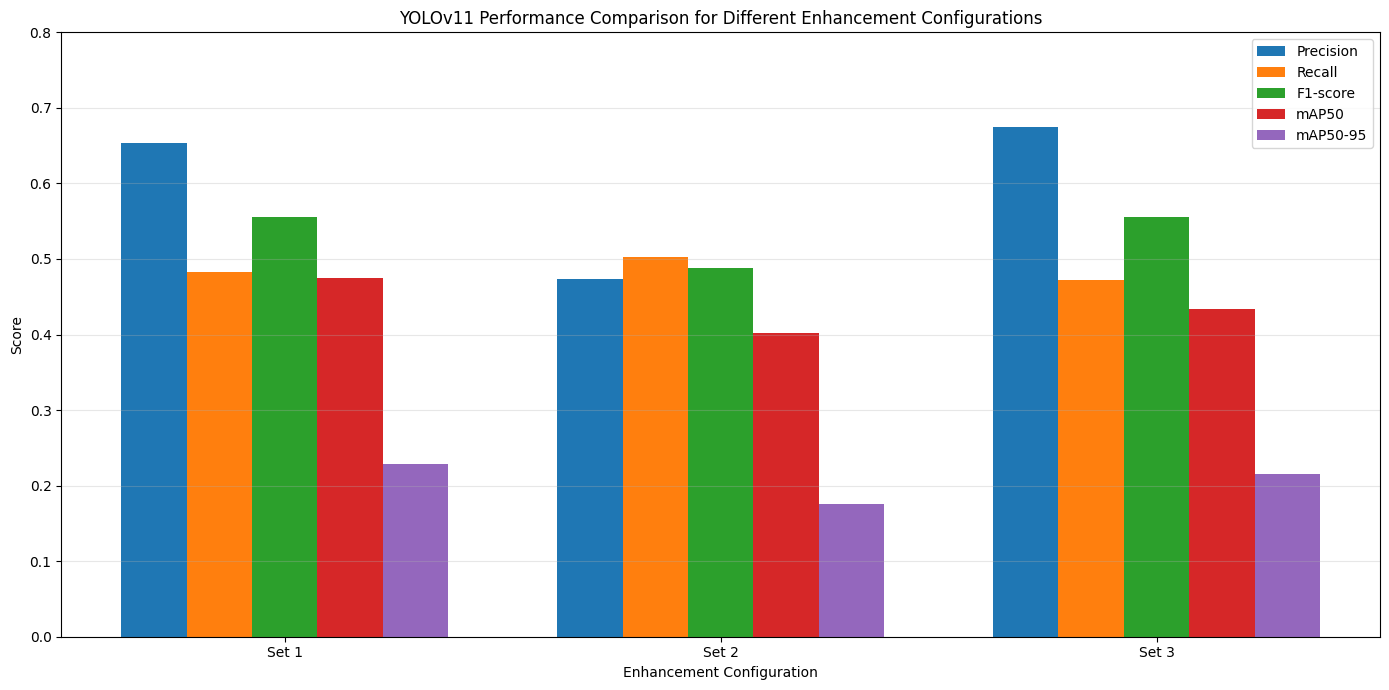

Chart saved successfully!
/content/drive/MyDrive/PCB-Defect-Inspection-lsp/runs/yolov11_test_performance_comparison.png


In [11]:
# ==========================================
# YOLOv11 Test Performance Comparison
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# Test results from the three enhancement configurations
sets = ["Set 1", "Set 2", "Set 3"]

precision = [0.653, 0.473, 0.675]
recall = [0.483, 0.503, 0.472]
f1_score = [0.555, 0.488, 0.555]
map50 = [0.475, 0.402, 0.434]
map50_95 = [0.229, 0.176, 0.216]


# ==========================================
# Create grouped bar chart
# ==========================================

x = np.arange(len(sets))
width = 0.15

plt.figure(figsize=(14, 7))

plt.bar(
    x - 2 * width,
    precision,
    width,
    label="Precision"
)

plt.bar(
    x - width,
    recall,
    width,
    label="Recall"
)

plt.bar(
    x,
    f1_score,
    width,
    label="F1-score"
)

plt.bar(
    x + width,
    map50,
    width,
    label="mAP50"
)

plt.bar(
    x + 2 * width,
    map50_95,
    width,
    label="mAP50-95"
)


# ==========================================
# Labels and formatting
# ==========================================

plt.xlabel(
    "Enhancement Configuration"
)

plt.ylabel(
    "Score"
)

plt.title(
    "YOLOv11 Performance Comparison for Different Enhancement Configurations"
)

plt.xticks(
    x,
    sets
)

plt.ylim(
    0,
    0.8
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()


# ==========================================
# Save result to Google Drive
# ==========================================

SAVE_PATH = (
    "/content/drive/MyDrive/"
    "PCB-Defect-Inspection-lsp/runs/"
    "yolov11_test_performance_comparison.png"
)

plt.savefig(
    SAVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully!")
print(SAVE_PATH)

In [15]:
import os

SAVE_PATH = "/content/drive/MyDrive/PCB-Defect-Inspection-lsp/runs/yolov11_test_performance_comparison.png"

plt.savefig(
    SAVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved!")
print(SAVE_PATH)
print("File exists:", os.path.exists(SAVE_PATH))

<Figure size 640x480 with 0 Axes>

Saved!
/content/drive/MyDrive/PCB-Defect-Inspection-lsp/runs/yolov11_test_performance_comparison.png
File exists: True
